In [5]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [6]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

print("Training images shape:", x_train.shape)
print("Testing images shape:", x_test.shape)

Training images shape: (50000, 32, 32, 3)
Testing images shape: (10000, 32, 32, 3)


In [7]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [8]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

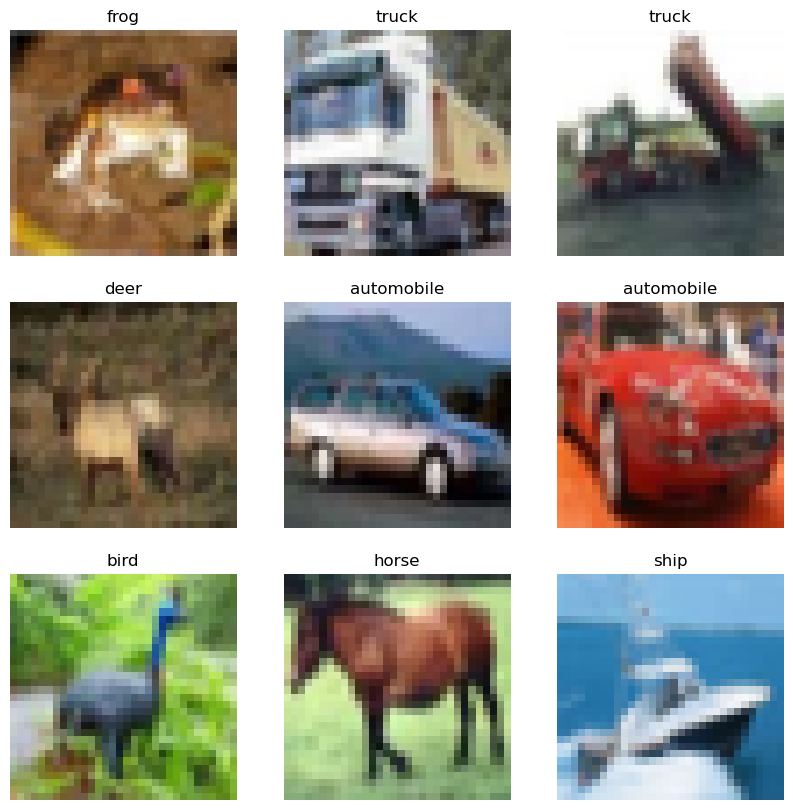

In [9]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

In [10]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dense(10,activation='softmax'))

C:\Users\nitik\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test,y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 23ms/step - accuracy: 0.4417 - loss: 1.5267 - val_accuracy: 0.5706 - val_loss: 1.2135
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.5922 - loss: 1.1528 - val_accuracy: 0.6111 - val_loss: 1.1091
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6438 - loss: 1.0119 - val_accuracy: 0.6457 - val_loss: 1.0068
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6806 - loss: 0.9139 - val_accuracy: 0.6645 - val_loss: 0.9645
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.7096 - loss: 0.8365 - val_accuracy: 0.6906 - val_loss: 0.9033
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.7276 - loss: 0.7763 - val_accuracy: 0.7030 - val_loss: 0.8608
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.7474 - loss: 0.7245 - val_accuracy: 0.7017 - val_loss: 0.8614
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.7636 -

In [13]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7202 - loss: 0.8583
Test Accuracy: 0.7202000021934509


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


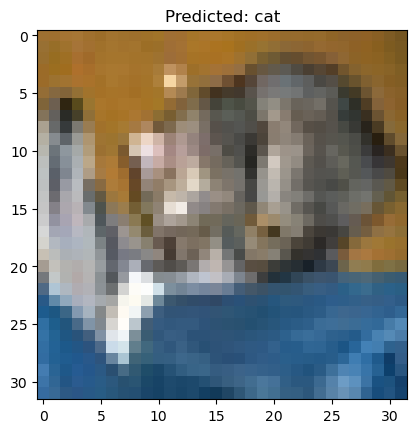

In [14]:
predictions = model.predict(x_test)

plt.imshow(x_test[0])
plt.title("Predicted: " + class_names[np.argmax(predictions[0])])
plt.show()

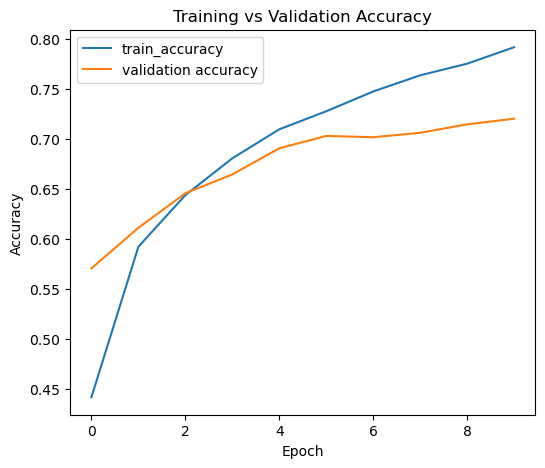

In [15]:
plt.figure(figsize=(6,5))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

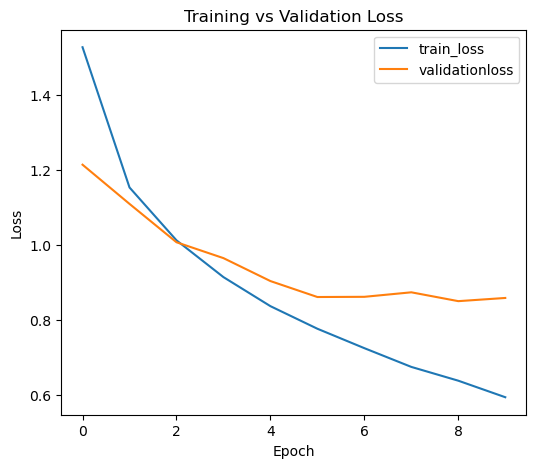

In [16]:
plt.figure(figsize=(6,5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="validationloss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()